# Multiwell Posterior with mPCN

Generate a 2D dataset from the 16-polynomic wells map and run a basic mPCN chain to estimate $(x_1, x_2)$.

In [1]:
import os
import sys
from pathlib import Path
import time

import numpy as np
import matplotlib.pyplot as plt

repo_root = Path.cwd().resolve()
while repo_root != repo_root.parent and not (repo_root / 'pyproject.toml').exists():
    repo_root = repo_root.parent
src_path = repo_root / 'src'
if src_path.exists() and str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from multiproposal.algorithms.mpcn import mpcn_step
from multiproposal.algorithms.mess import mess_step
from multiproposal.algorithms.effective_sample_size import estimate_effective_sample_size
from multiproposal.problems.toy_custom_likelihood import ToyCustomLikelihood2D
from multiproposal.plotting.diagnostics import make_hist_grid_comps



In [2]:
def f_16polynomic_wells(x):
    x1, x2 = x
    comp1 = (x1 ** 2 - 1) * (x1 ** 2 - 4)
    comp2 = (x2 ** 2 - 1) * (x2 ** 2 - 4)
    return np.array([comp1, comp2])

def log_likelihood_16polynomic(x, y_obs, sigma=0.3):
    r = f_16polynomic_wells(x) - y_obs
    return -0.5 * np.dot(r, r) / (sigma ** 2)

In [3]:
# Match the data-generation pattern from the toy notebook
sigma_noise = 1.0
prior_std = 1
prior_cov = prior_std ** 2 * np.array([[1.0, 0], [0, 1]])
prior_mean = np.zeros(2)

rng = np.random.default_rng(202)
prior_sample = rng.multivariate_normal(prior_mean, prior_cov)
theta_true = f_16polynomic_wells(prior_sample)
y_obs = theta_true + rng.normal(0.0, sigma_noise, size=theta_true.shape)

def log_likelihood(x):
    return log_likelihood_16polynomic(x, y_obs, sigma=sigma_noise)

problem = ToyCustomLikelihood2D(
    log_likelihood_fn=log_likelihood,
    prior_mean=prior_mean,
    prior_cov=prior_cov,
)

print('y_obs:', y_obs)
print('True x:', prior_sample)
print('Log-posterior at prior mean:', problem.log_posterior(prior_mean))

y_obs: [-2.72358526  1.22300603]
True x: [ 1.81172035 -0.72905356]
Log-posterior at prior mean: -26.459147097660278


In [4]:
# MCMC configuration
n_iters = 50000
rho = 0.1
n_props = 20
mess_M = 5
run_mess = True  # Toggle MESS run + plots
seed_mcmc = 202
rng_mpcn = np.random.default_rng(seed_mcmc)
rng_mess = np.random.default_rng(seed_mcmc)
x0 = problem.sample_prior(rng_mpcn)

# mPCN chain
chain_mpcn = np.zeros((n_iters + 1, problem.dim), dtype=float)
accepted_index = np.zeros(n_iters, dtype=int)
chain_mpcn[0] = x0
x = x0.copy()
t0 = time.perf_counter()
for t in range(n_iters):
    x_new, idx = mpcn_step(x, problem, rng_mpcn, rho=rho, n_props=n_props, return_idx=True)
    accepted_index[t] = idx
    x = x_new
    chain_mpcn[t + 1] = x
runtime_mpcn_sec = time.perf_counter() - t0

accept_rate = np.mean(accepted_index != 0)
accepted_idx = accepted_index.astype(int)
print(f'mPCN acceptance rate (state changed): {accept_rate:.3f}')
print('mPCN accepted indices (first 20):', accepted_idx[:20])
print(f'mPCN runtime (sec): {runtime_mpcn_sec:.2f}')

# MESS chain (M=5, no LP)
if run_mess:
    chain_mess = np.zeros((n_iters + 1, problem.dim), dtype=float)
    chain_mess[0] = x0
    x = x0.copy()
    t0 = time.perf_counter()
    for t in range(n_iters):
        x, _, _ = mess_step(
            x,
            problem,
            rng_mess,
            M=mess_M,
            use_lp=False,
            distance_metric='angular',
            lam=0.0,
        )
        chain_mess[t + 1] = x
    runtime_mess_sec = time.perf_counter() - t0
    print('MESS run completed.')
    print(f'MESS runtime (sec): {runtime_mess_sec:.2f}')
else:
    chain_mess = None
    runtime_mess_sec = 0.0
    print('MESS disabled (run_mess=False).')

mPCN acceptance rate (state changed): 0.567
mPCN accepted indices (first 20): [ 0  3  0  0 19  0  0  7 16 10 14  0  9  9  0  1  9 18 19  0]
mPCN runtime (sec): 2.98
MESS run completed.
MESS runtime (sec): 1.92


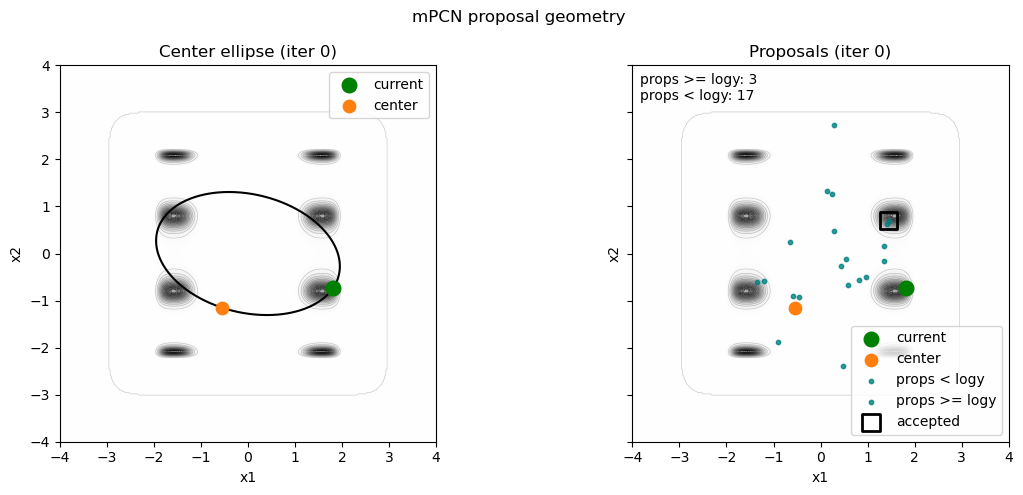

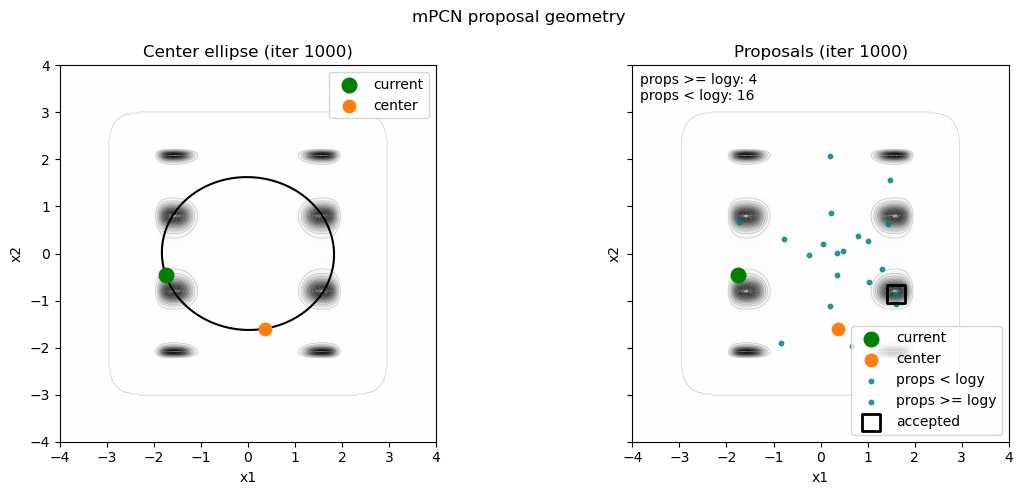

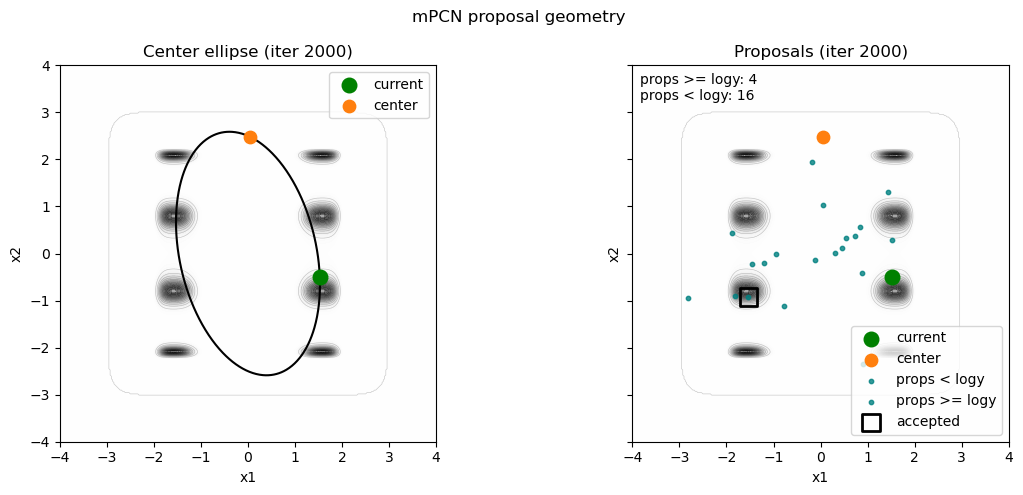

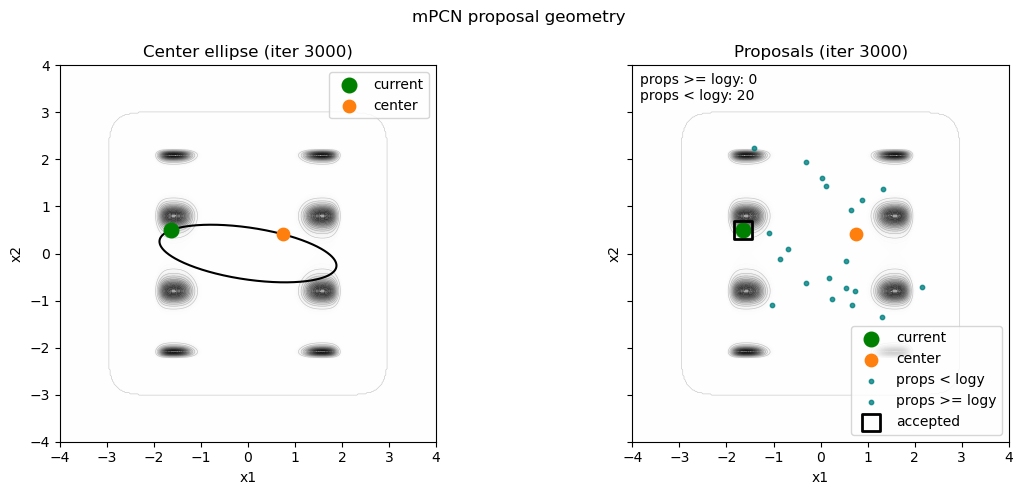

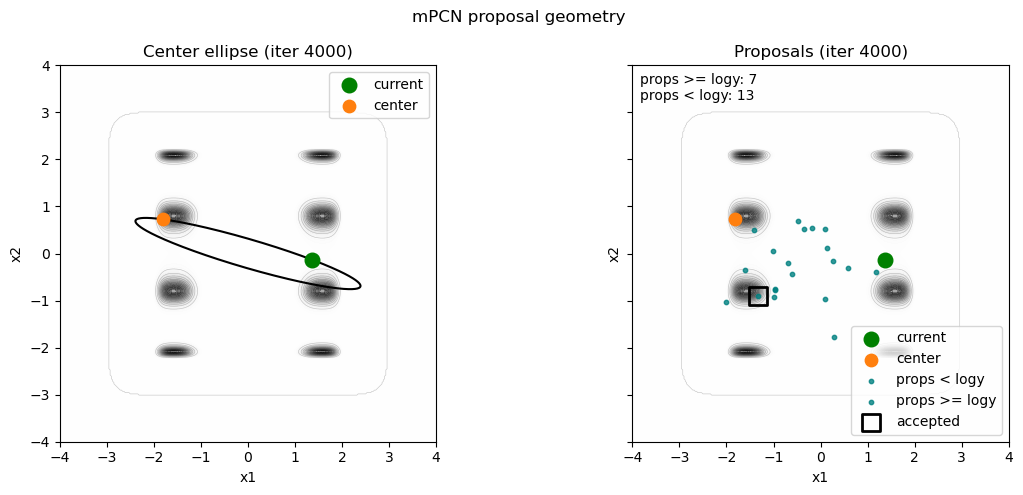

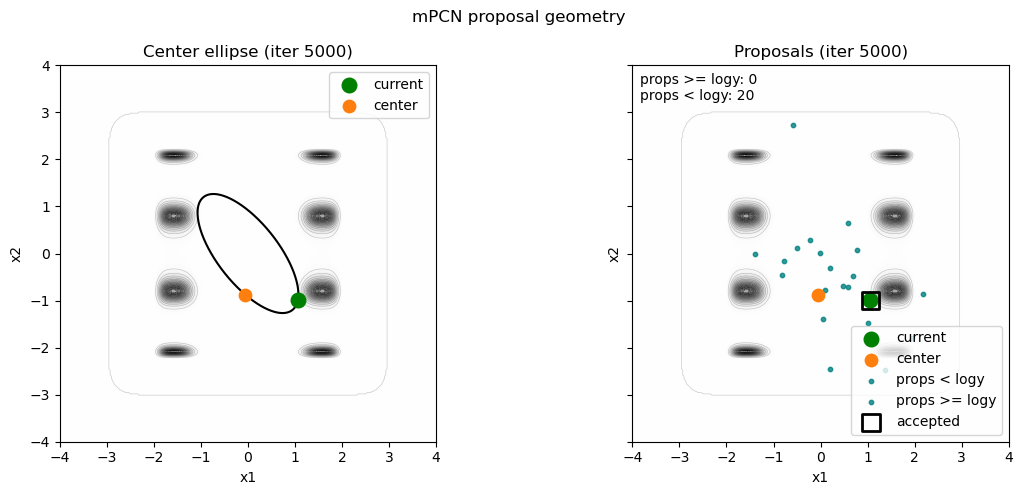

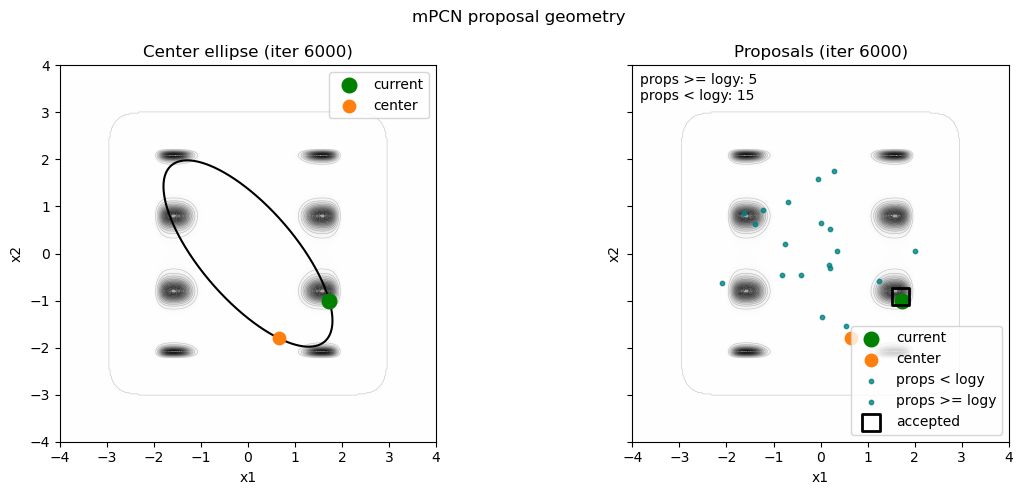

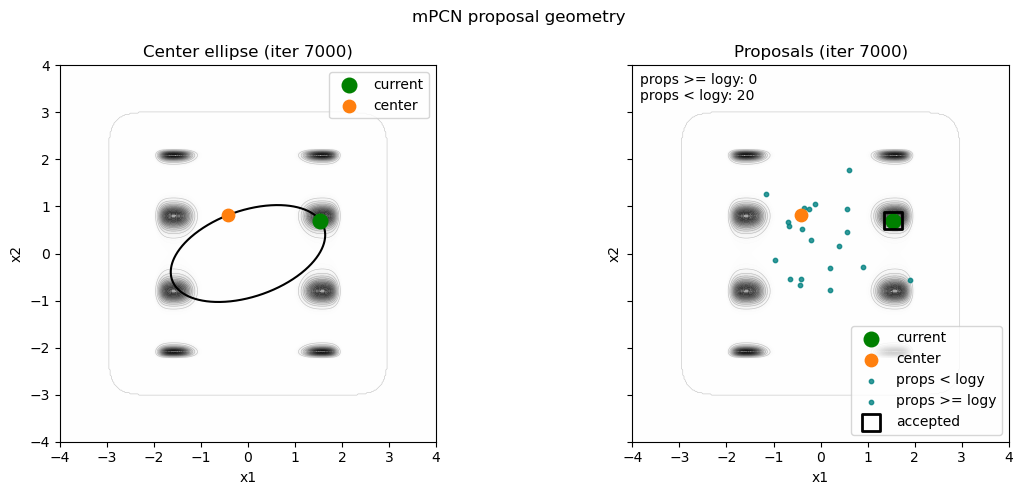

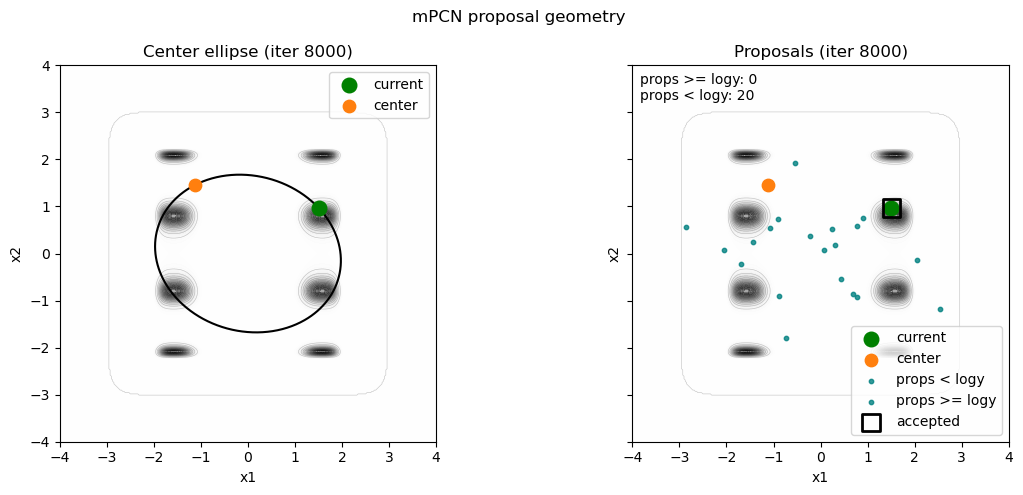

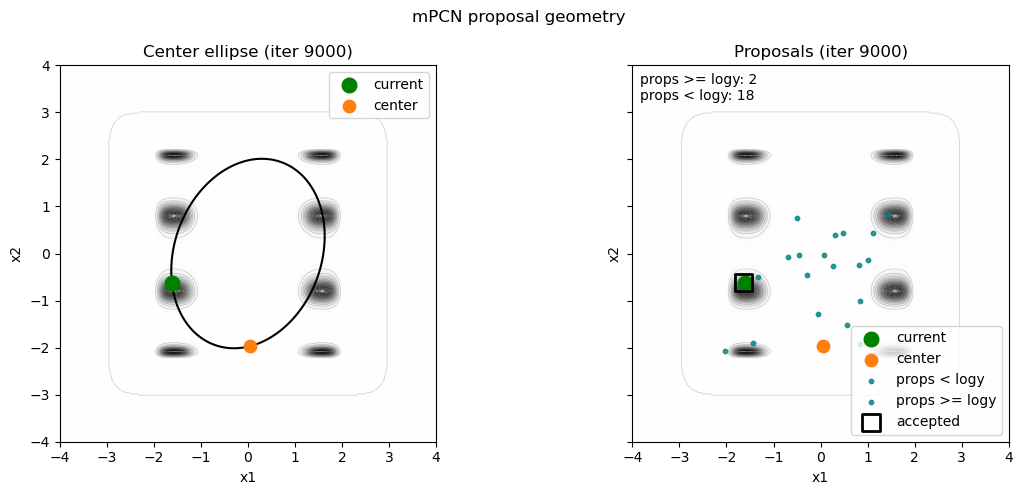

In [5]:
# Proposal illustrations for selected iterations (separate diagnostic run)
plot_iters = [nr for nr in np.arange(0, 10000, 1000)]  # Choose which iterations to visualize
plot_iters = sorted(set(plot_iters))
n_iters_diag = max(plot_iters) + 1
seed_mpcn_diag = 202
rng_diag = np.random.default_rng(seed_mpcn_diag)
x0_diag = x0.copy()

grid_min = -4.0
grid_max = 4.0
grid = np.linspace(grid_min, grid_max, 300)
X1, X2 = np.meshgrid(grid, grid)
log_like = np.zeros_like(X1)
for i in range(X1.shape[0]):
    for j in range(X1.shape[1]):
        x_grid = np.array([X1[i, j], X2[i, j]])
        log_like[i, j] = log_likelihood_16polynomic(x_grid, y_obs, sigma=sigma_noise)
log_like -= log_like.max()
like_density = np.exp(log_like)

theta = np.linspace(0.0, 2.0 * np.pi, 800)
levels_fill = 50
levels_line = 14

def mpcn_step_diagnostics(x, problem, rng, rho=0.9, n_props=10):
    mu = problem.prior_mean()
    eta = np.sqrt(1.0 - rho * rho)
    nu_c = problem.L @ rng.standard_normal(problem.dim)
    x_center = mu + rho * (x - mu) + eta * nu_c
    z = rng.standard_normal((problem.dim, n_props))
    props = (mu[:, None] + rho * (x_center - mu)[:, None] + eta * (problem.L @ z)).T
    candidates = np.vstack([x[None, :], props])
    log_w = np.array([problem.log_likelihood(c) for c in candidates])
    log_w -= np.max(log_w)
    weights = np.exp(log_w)
    idx = rng.choice(n_props + 1, p=weights / weights.sum())
    return x_center, nu_c, props, candidates, log_w, idx

def plot_mpcn_snapshot(iter_idx, x, x_center, nu_c, props, candidates, logy, accepted_idx):
    mu = problem.prior_mean()
    ellipse = mu + np.cos(theta)[:, None] * (x - mu) + np.sin(theta)[:, None] * nu_c
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
    for ax in axes:
        ax.contourf(X1, X2, like_density, levels=levels_fill, cmap="Greys", alpha=0.35)
        ax.contour(X1, X2, like_density, levels=levels_line, colors="black", linewidths=0.5, alpha=0.2)
        ax.set_aspect("equal", adjustable="box")
        ax.set_xlabel("x1")
        ax.set_ylabel("x2")
        ax.grid(False)
    axes[0].plot(ellipse[:, 0], ellipse[:, 1], color="black", linewidth=1.5, zorder=2)
    axes[0].scatter([x[0]], [x[1]], color="green", s=110, marker="o", label="current", zorder=3)
    axes[0].scatter([x_center[0]], [x_center[1]], color="tab:orange", s=80, marker="o", label="center", zorder=3)
    axes[0].set_title(f"Center ellipse (iter {iter_idx})")
    axes[0].legend(loc="upper right")

    prop_log_like = np.array([problem.log_likelihood(p) for p in props])
    above = prop_log_like >= logy
    n_above = int(np.sum(above))
    n_below = int(props.shape[0] - n_above)
    axes[1].scatter([x[0]], [x[1]], color="green", s=110, marker="o", label="current", zorder=3)
    axes[1].scatter([x_center[0]], [x_center[1]], color="tab:orange", s=80, marker="o", label="center", zorder=3)
    axes[1].scatter(props[~above, 0], props[~above, 1], color="teal", s=10, alpha=0.8, label="props < logy", zorder=2)
    axes[1].scatter(props[above, 0], props[above, 1], color="teal", s=10, alpha=0.8, label="props >= logy", zorder=2)
    accepted_point = candidates[accepted_idx]
    axes[1].scatter([accepted_point[0]], [accepted_point[1]], facecolors="none", edgecolors="black",
                    s=160, marker="s", linewidths=2.0, label="accepted", zorder=4)
    axes[1].text(
        0.02,
        0.98,
        f"props >= logy: {n_above}\nprops < logy: {n_below}",
        transform=axes[1].transAxes,
        va="top",
        ha="left",
        fontsize=10,
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"),
    )
    axes[1].set_title(f"Proposals (iter {iter_idx})")
    axes[1].legend(loc="lower right")
    fig.suptitle("mPCN proposal geometry")
    fig.tight_layout()
    plt.show()

snapshots = {}
x = x0_diag.copy()
for t in range(n_iters_diag):
    log_l0 = problem.log_likelihood(x)
    logy = log_l0 + np.log(rng_diag.uniform())
    x_center, nu_c, props, candidates, _, idx = mpcn_step_diagnostics(
        x, problem, rng_diag, rho=rho, n_props=n_props
    )
    if t in plot_iters:
        snapshots[t] = (x.copy(), x_center.copy(), nu_c.copy(), props.copy(), candidates.copy(), logy, idx)
    x = candidates[idx]

for t in plot_iters:
    x_snap, x_center_snap, nu_c_snap, props_snap, candidates_snap, logy_snap, idx_snap = snapshots[t]
    plot_mpcn_snapshot(t, x_snap, x_center_snap, nu_c_snap, props_snap, candidates_snap, logy_snap, idx_snap)

In [6]:
# Runtime + ESS/MSJD per minute
burn_in_metric = 500
max_lag = 500

def compute_msjd_per_param(chain):
    if chain.shape[0] < 2:
        return np.zeros(chain.shape[1])
    jumps = np.diff(chain, axis=0)
    msjd = np.mean(jumps * jumps, axis=0)
    return msjd

def compute_ess_per_param(chain, max_lag):
    if chain.shape[0] < 2:
        return np.zeros(chain.shape[1])
    variances = np.var(chain, axis=0)
    if np.all(variances == 0):
        return np.zeros(chain.shape[1])
    ess_vals = estimate_effective_sample_size(chain, max_lag=max_lag)
    ess_vals = np.asarray(ess_vals, dtype=float)
    ess_vals[variances == 0] = 0.0
    return ess_vals

def summarize_chain_metrics(chain, runtime_sec, label):
    post = chain[burn_in_metric:]
    ess_vals = compute_ess_per_param(post, max_lag=max_lag)
    msjd_vals = compute_msjd_per_param(post)
    ess_mean = float(np.nanmean(ess_vals)) if ess_vals.size else 0.0
    msjd_mean = float(np.nanmean(msjd_vals)) if msjd_vals.size else 0.0
    runtime_min = runtime_sec / 60.0
    ess_per_min = ess_mean / runtime_min if runtime_min > 0 else np.nan
    print(f"{label} runtime (min): {runtime_min:.2f}")
    print(f"{label} mean ESS: {ess_mean:.1f}")
    print(f"{label} mean MSJD: {msjd_mean:.4g}")
    print(f"{label} ESS per minute: {ess_per_min:.2f}")
    return {
        'runtime_sec': runtime_sec,
        'runtime_min': runtime_min,
        'ess_mean': ess_mean,
        'msjd_mean': msjd_mean,
        'ess_per_min': ess_per_min,
    }

metrics_mpcn = summarize_chain_metrics(chain_mpcn, runtime_mpcn_sec, 'mPCN')
metrics_mess = None
if run_mess and chain_mess is not None:
    metrics_mess = summarize_chain_metrics(chain_mess, runtime_mess_sec, 'MESS (M=5)')
else:
    print('Skipping MESS metrics (run_mess=False).')

Estimating ESS for each parameter.
mPCN runtime (min): 0.05
mPCN mean ESS: 16966.7
mPCN mean MSJD: 1.667
mPCN ESS per minute: 341758.40
Estimating ESS for each parameter.
MESS (M=5) runtime (min): 0.03
MESS (M=5) mean ESS: 24606.1
MESS (M=5) mean MSJD: 2.071
MESS (M=5) ESS per minute: 767636.11


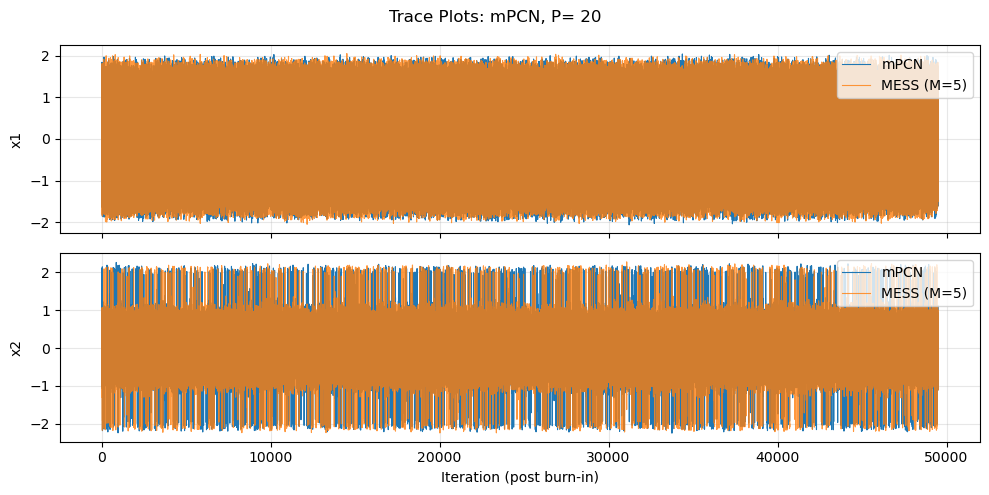

In [7]:
burn_in = 500
post_chain_mpcn = chain_mpcn[burn_in:]
post_chain_mess = chain_mess[burn_in:] if run_mess and chain_mess is not None else None

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
axes[0].plot(post_chain_mpcn[:, 0], color='tab:blue', linewidth=0.8, label='mPCN')
if post_chain_mess is not None:
    axes[0].plot(post_chain_mess[:, 0], color='tab:orange', linewidth=0.8, alpha=0.8, label='MESS (M=5)')
axes[0].set_ylabel('x1')
axes[0].grid(alpha=0.3)
axes[0].legend(loc='upper right')

axes[1].plot(post_chain_mpcn[:, 1], color='tab:blue', linewidth=0.8, label='mPCN')
if post_chain_mess is not None:
    axes[1].plot(post_chain_mess[:, 1], color='tab:orange', linewidth=0.8, alpha=0.8, label='MESS (M=5)')
axes[1].set_ylabel('x2')
axes[1].set_xlabel('Iteration (post burn-in)')
axes[1].grid(alpha=0.3)
axes[1].legend(loc='upper right')

fig.suptitle(f'Trace Plots: mPCN, P= {n_props}')
fig.tight_layout()
plt.show()

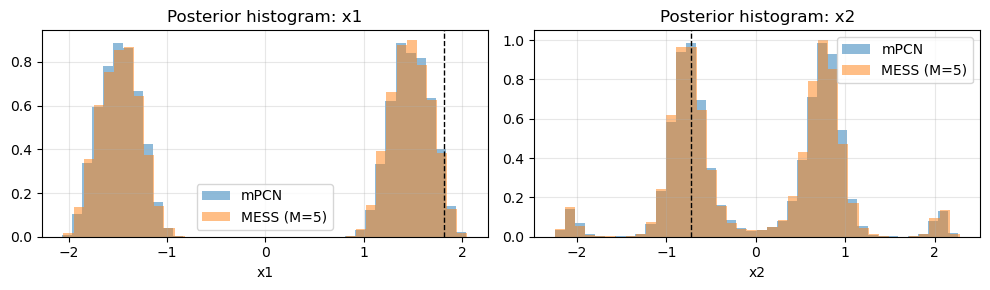

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
bins = 40
axes[0].hist(post_chain_mpcn[:, 0], bins=bins, density=True, color='tab:blue', alpha=0.5, label='mPCN')
if post_chain_mess is not None:
    axes[0].hist(post_chain_mess[:, 0], bins=bins, density=True, color='tab:orange', alpha=0.5, label='MESS (M=5)')
axes[0].axvline(prior_sample[0], color='black', linestyle='--', linewidth=1)
axes[0].set_title('Posterior histogram: x1')
axes[0].set_xlabel('x1')
axes[0].grid(alpha=0.3)
axes[0].legend(loc='best')

axes[1].hist(post_chain_mpcn[:, 1], bins=bins, density=True, color='tab:blue', alpha=0.5, label='mPCN')
if post_chain_mess is not None:
    axes[1].hist(post_chain_mess[:, 1], bins=bins, density=True, color='tab:orange', alpha=0.5, label='MESS (M=5)')
axes[1].axvline(prior_sample[1], color='black', linestyle='--', linewidth=1)
axes[1].set_title('Posterior histogram: x2')
axes[1].set_xlabel('x2')
axes[1].grid(alpha=0.3)
axes[1].legend(loc='best')

fig.tight_layout()
plt.show()

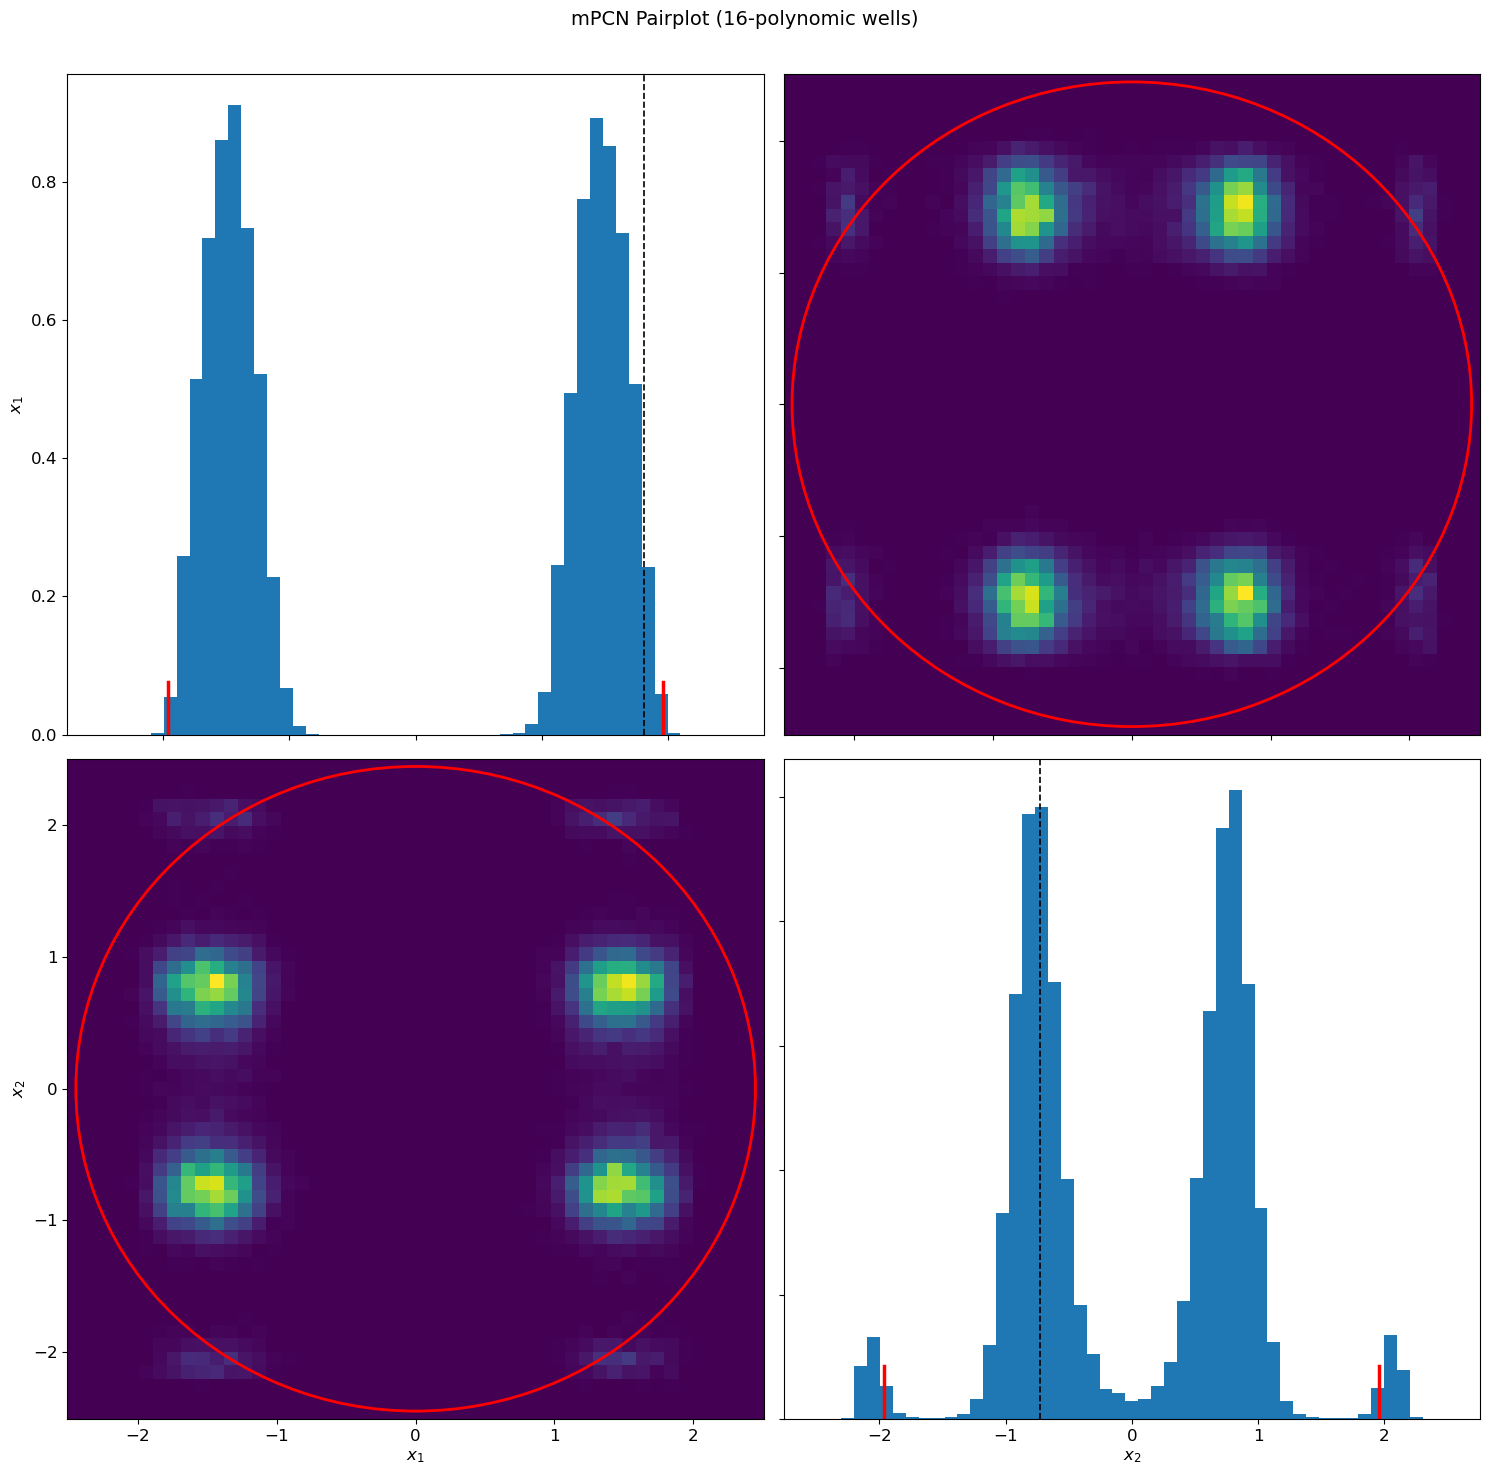

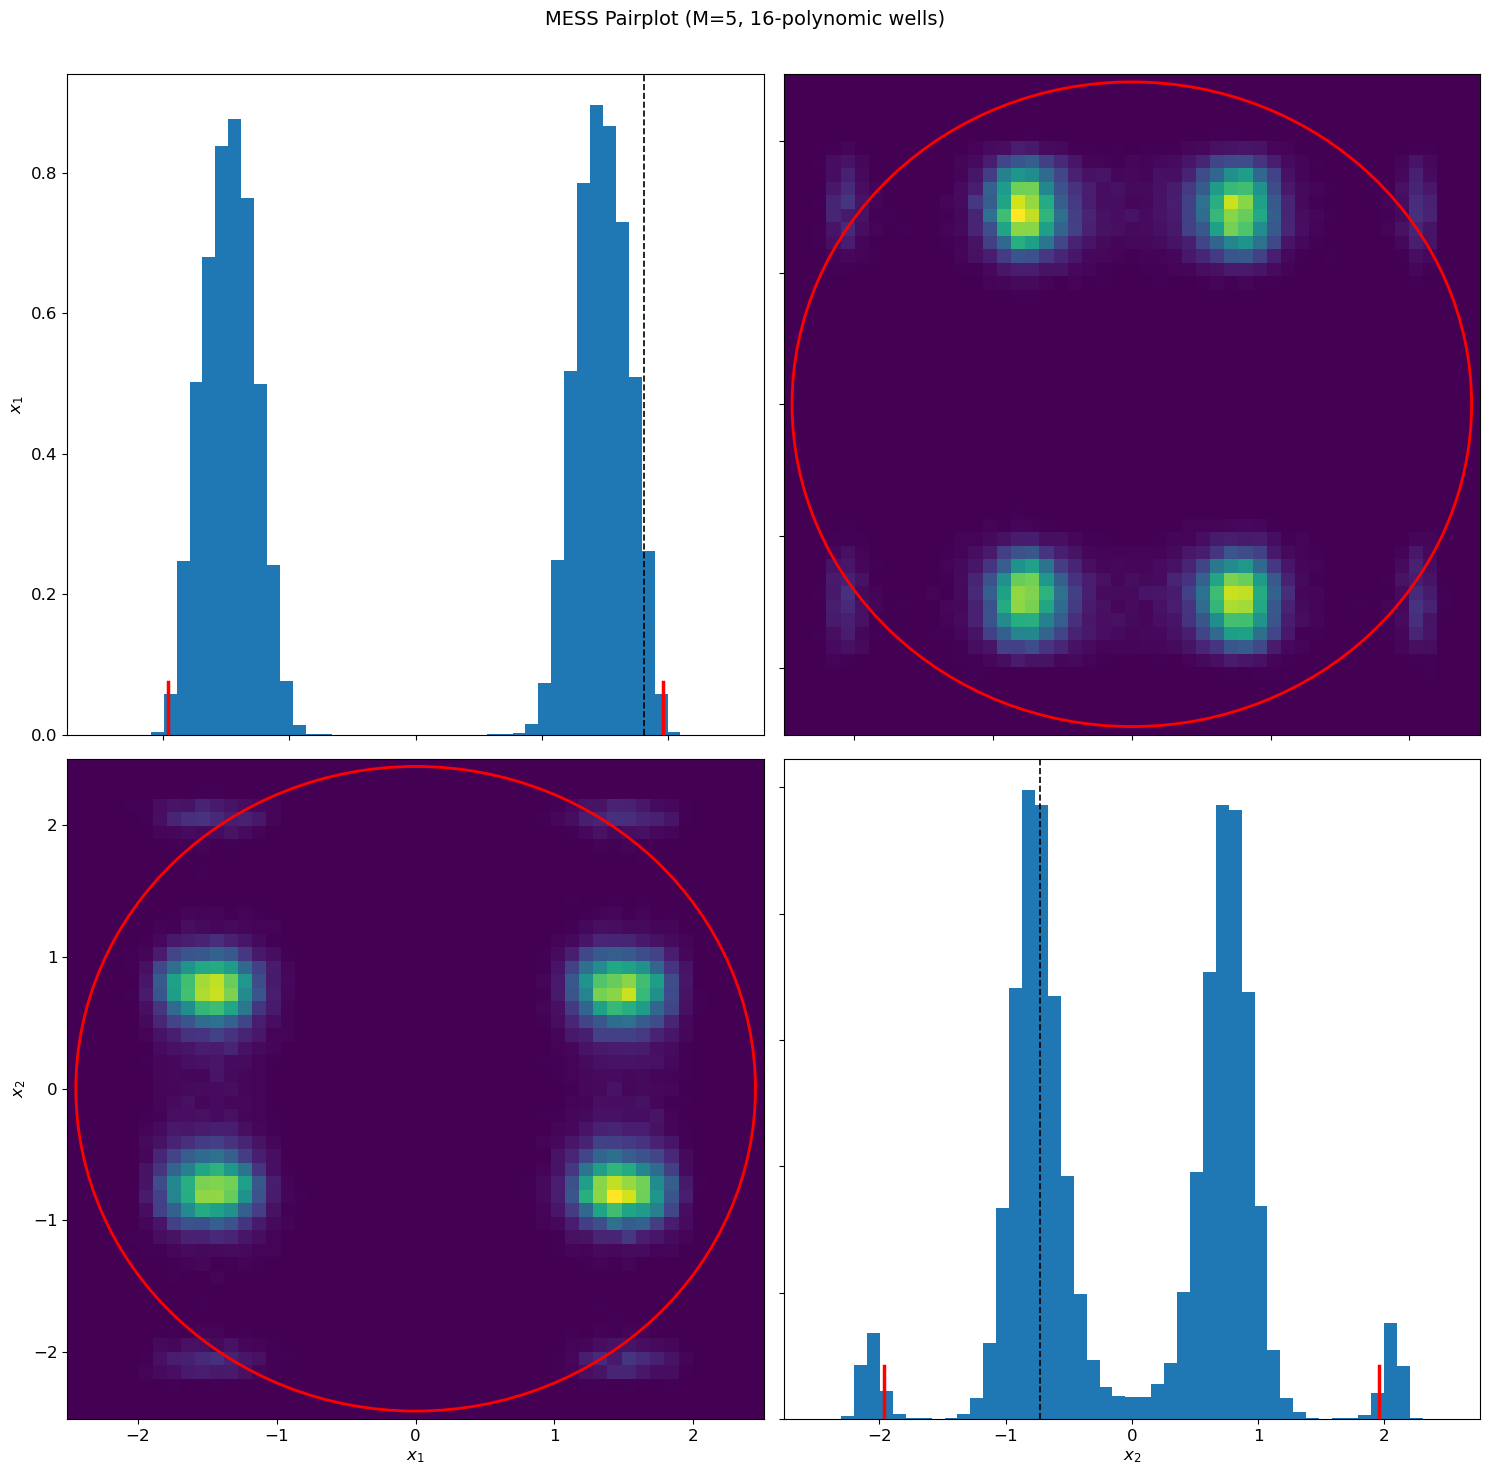

In [19]:
if post_chain_mess is not None:
    combined = np.vstack([post_chain_mpcn, post_chain_mess])
else:
    combined = post_chain_mpcn
R = 1.1 * np.max(np.abs(combined))
dr = 0.1

_ = make_hist_grid_comps(
    R=R,
    dr=dr,
    samples=post_chain_mpcn,
    comp_list=[0, 1],
    save_path=None,
    C=prior_cov,
    beta=0.95,
    hide_plot=False,
    label_map={0: '$x_1$', 1: '$x_2$'},
    font_size=12,
    title='mPCN Pairplot (16-polynomic wells)',
    true_values=prior_sample,
 )

if post_chain_mess is not None:
    _ = make_hist_grid_comps(
        R=R,
        dr=dr,
        samples=post_chain_mess,
        comp_list=[0, 1],
        save_path=None,
        C=prior_cov,
        beta=0.95,
        hide_plot=False,
        label_map={0: '$x_1$', 1: '$x_2$'},
        font_size=12,
        title='MESS Pairplot (M=5, 16-polynomic wells)',
        true_values=prior_sample,
    )